# The Steepener Trade

## Data Imports

In [3]:
import pandas as pd

#DATE = '2023-06-30'
DATE = '2024-01-02'

FILE_DATA = f'../data/steepener_trade_{DATE}.xlsx'

info = pd.read_excel(FILE_DATA,sheet_name='info').set_index('KYTREASNO').T
clean = pd.read_excel(FILE_DATA,sheet_name='clean price').set_index('quote date')
dirty = pd.read_excel(FILE_DATA,sheet_name='dirty price').set_index('quote date')
duration = pd.read_excel(FILE_DATA,sheet_name='duration').set_index('quote date')

print("Dirty Prices:")
display(dirty)
print("Duration:")
display(duration)


Dirty Prices:


,207652,208147
quote date,,
2023-11-09,90.978261,99.000000
2023-11-10,90.940217,98.789062
2023-11-13,91.005774,98.882812
2023-11-14,91.397418,100.414062
2023-11-15,91.253906,99.742188
...,...,...
2025-05-23,97.904452,100.762021
2025-05-27,97.907937,101.224864
2025-05-28,97.913829,100.967561


Duration:


,207652,208147
quote date,,
2023-11-09,2.135193,8.173725
2023-11-10,2.132450,8.168483
2023-11-13,2.124233,8.160898
2023-11-14,2.121523,8.174992
2023-11-15,2.118771,8.164722
...,...,...
2025-05-23,0.607258,7.147798
2025-05-27,0.596299,7.140169
2025-05-28,0.593559,7.135270


### 1.1
- 50 million long in the 2 year bond

In [47]:
long_position = 50*(10**6)  # $50 million
interest_ratio = duration.loc['2023-11-09',:].loc[207652] * dirty.loc['2023-11-09',:].loc[207652] / (duration.loc['2023-11-09',:].loc[208147] * dirty.loc['2023-11-09',:].loc[208147])
short_dollar = long_position * interest_ratio
print(f"short_dollar: {short_dollar}")
two_year_bond = long_position / dirty.loc['2023-11-09',:].loc[207652]
print(f"two_year_bond: {two_year_bond}")
ten_year_bond = short_dollar / dirty.loc['2023-11-09',:].loc[208147]
print(f"ten_year_bond: {ten_year_bond}")

short_dollar: 12002995.481079713
two_year_bond: 549581.8399044205
ten_year_bond: 121242.37859676477


### 1.2 Dynamic Hedge

Final P&L: 32123451.97 $


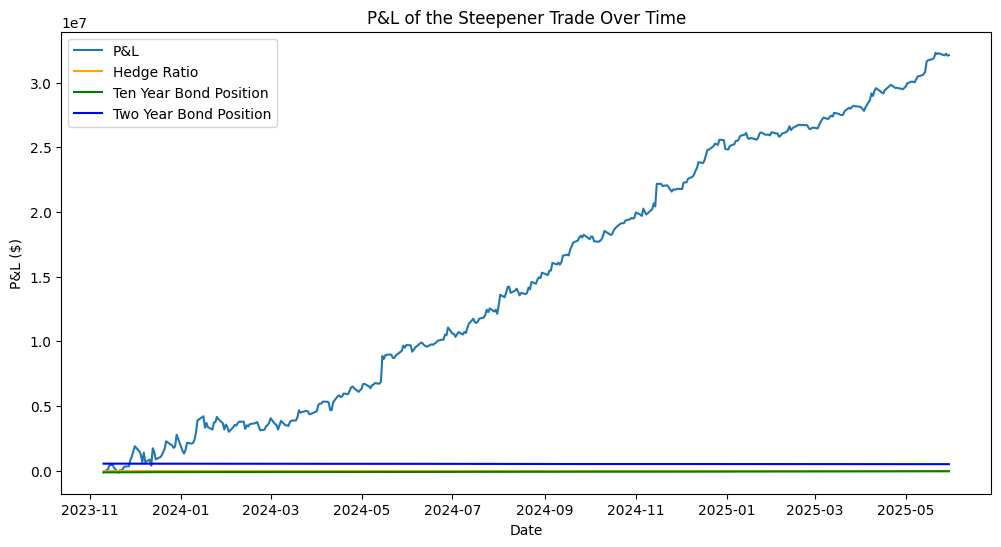

In [48]:
net_pnl = 0
net_pnl_list = []
two_year_pnl = 0
ten_year_pnl = 0
two_year_pnl_list = []
ten_year_pnl_list = []
hedge_ratio_list = []
ten_year_bond_list = []
two_year_bond_list = []

for i in range(len(dirty)):
    if i == 0:
        continue
    date = dirty.index[i]
    dirty_2y_prev = dirty.iloc[i-1,:].loc[207652]
    dirty_10y_prev = dirty.iloc[i-1,:].loc[208147]
    dirty_2y_curr = dirty.iloc[i,:].loc[207652]
    dirty_10y_curr = dirty.iloc[i,:].loc[208147]

    net_pnl += two_year_bond * (dirty_2y_curr - dirty_2y_prev) - ten_year_bond * (dirty_10y_curr - dirty_10y_prev)
    net_pnl_list.append((date, net_pnl))
    two_year_pnl += two_year_bond * (dirty_2y_curr - dirty_2y_prev)
    two_year_pnl_list.append((date, two_year_pnl))
    ten_year_pnl += - ten_year_bond * (dirty_10y_curr - dirty_10y_prev)
    ten_year_pnl_list.append((date, ten_year_pnl))

    two_year_bond = long_position / dirty.iloc[i,:].loc[207652]
    interest_ratio = duration.iloc[i,:].loc[207652] * dirty.iloc[i,:].loc[207652] / (duration.iloc[i,:].loc[208147] * dirty.iloc[i,:].loc[208147])
    hedge_ratio_list.append((date, interest_ratio))
    short_dollar = long_position * interest_ratio
    ten_year_bond = short_dollar / dirty.iloc[i,:].loc[208147]
    ten_year_bond_list.append((date, ten_year_bond))
    two_year_bond_list.append((date, two_year_bond))


ten_year_bond_list = [(x[0], x[1]*-1) for x in ten_year_bond_list]

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot([x[0] for x in pnl_list], [x[1] for x in pnl_list], label='P&L')
plt.plot([x[0] for x in hedge_ratio_list], [x[1] for x in hedge_ratio_list], label='Hedge Ratio', color='orange')
plt.plot([x[0] for x in ten_year_bond_list], [x[1] for x in ten_year_bond_list], label='Ten Year Bond Position', color='green')
plt.plot([x[0] for x in two_year_bond_list], [x[1] for x in two_year_bond_list], label='Two Year Bond Position', color='blue')
plt.xlabel('Date')
plt.ylabel('P&L ($)')
plt.title('P&L of the Steepener Trade Over Time')
plt.legend()
print(f"Final P&L: {pnl:.2f} $")

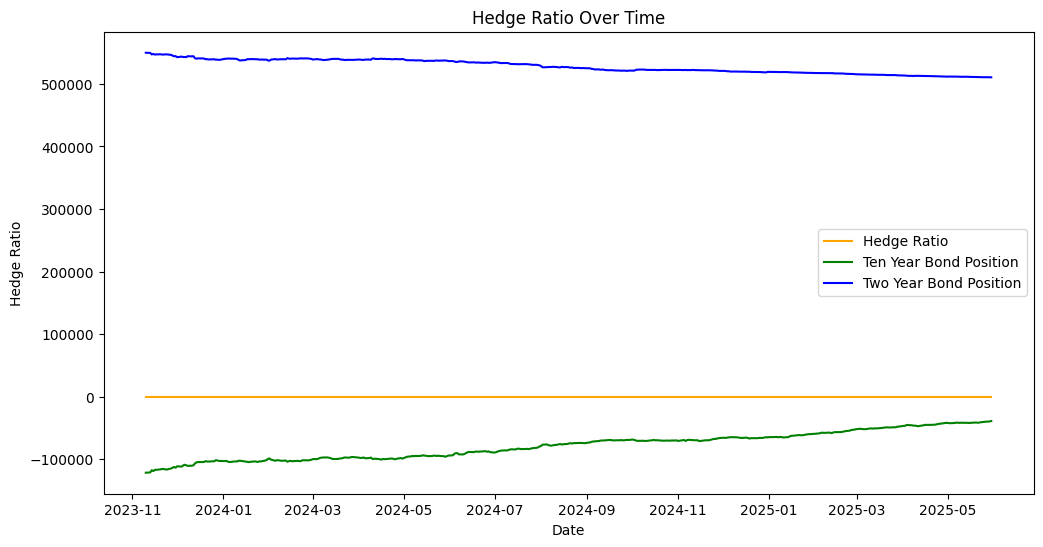

In [49]:
plt.figure(figsize=(12,6))
plt.plot([x[0] for x in hedge_ratio_list], [x[1] for x in hedge_ratio_list], label='Hedge Ratio', color='orange')
plt.plot([x[0] for x in ten_year_bond_list], [x[1] for x in ten_year_bond_list], label='Ten Year Bond Position', color='green')
plt.plot([x[0] for x in two_year_bond_list], [x[1] for x in two_year_bond_list], label='Two Year Bond Position', color='blue')
plt.xlabel('Date')
plt.ylabel('Hedge Ratio')
plt.title('Hedge Ratio Over Time')
plt.legend()

In [50]:
final_10y_position = ten_year_bond_list[-1][1]
final_2y_position = two_year_bond_list[-1][1]
print(f"Final 10 Year Bond Position: {final_10y_position}")
print(f"Final 2 Year Bond Position: {final_2y_position}")

Final 10 Year Bond Position: -39036.82052409559
Final 2 Year Bond Position: 510469.7335181066


### 1.3 

In [51]:
first_day_profit = net_pnl_list[0][1]
print(f"First Day Profit: {first_day_profit}")
last_day_profit = net_pnl_list[-1][1]
print(f"Last Day Profit: {last_day_profit}")
two_year_first_day = two_year_pnl_list[0][1]
print(f"Two Year First Day Profit: {two_year_first_day}")
ten_year_first_day = ten_year_pnl_list[0][1]
print(f"Ten Year First Day Profit: {ten_year_first_day}")
two_year_last_day = two_year_pnl_list[-1][1]
print(f"Two Year Last Day Profit: {two_year_last_day}")
ten_year_last_day = ten_year_pnl_list[-1][1]
print(f"Ten Year Last Day Profit: {ten_year_last_day}")

result = pd.DataFrame({
    'Date': [x[0] for x in net_pnl_list],
    'Net P&L': [x[1] for x in net_pnl_list],
    '2Y P&L': [x[1] for x in two_year_pnl_list],
    '10Y P&L': [x[1] for x in ten_year_pnl_list]
})
display(result)

First Day Profit: 4666.559456279829
Last Day Profit: 3228197.471624508
Two Year First Day Profit: -20908.00477897524
Ten Year First Day Profit: 25574.564235255068
Two Year Last Day Profit: 3699638.093638829
Ten Year Last Day Profit: -471440.6220143234


,Date,Net P&L,2Y P&L,10Y P&L
0,2023-11-10,4.666559e+03,-2.090800e+04,25574.564235
1,2023-11-13,2.930766e+04,1.513604e+04,14171.622338
2,2023-11-14,5.899855e+04,2.303114e+05,-171312.860129
3,2023-11-15,5.951339e+04,1.518014e+05,-92288.014586
4,2023-11-16,6.379294e+04,2.486741e+05,-184881.186625
...,...,...,...,...
382,2025-05-23,3.242667e+06,3.676890e+06,-434222.516091
383,2025-05-27,3.225488e+06,3.678670e+06,-453181.428910
384,2025-05-28,3.238764e+06,3.681679e+06,-442915.134165
385,2025-05-29,3.223589e+06,3.683690e+06,-460100.987675


### 1.4

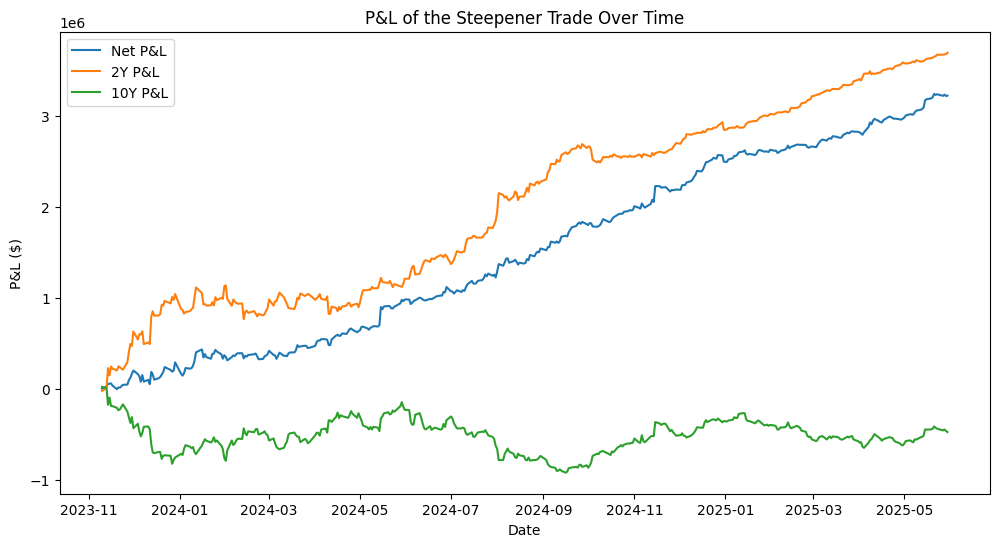

In [52]:
plt.figure(figsize=(12,6))
plt.plot(result['Date'], result['Net P&L'], label='Net P&L')
plt.plot(result['Date'], result['2Y P&L'], label='2Y P&L')
plt.plot(result['Date'], result['10Y P&L'], label='10Y P&L')
plt.xlabel('Date')
plt.ylabel('P&L ($)')
plt.title('P&L of the Steepener Trade Over Time')
plt.legend()

### 1.5 Coupons

In [53]:
display(info)

KYTREASNO,207652,208147
type,note,note
quote date,2024-01-02 00:00:00,2024-01-02 00:00:00
issue date,2020-12-31 00:00:00,2023-11-15 00:00:00
maturity date,2025-12-31 00:00:00,2033-11-15 00:00:00
ttm,1.995893,9.869952
accrual fraction,0.010989,0.263736
cpn rate,0.375,4.5
bid,92.578125,104.578125
ask,92.59375,104.640625
price,92.585938,104.609375


10 year bond on 2023-11-10 00:00:00 is at clean price. Cashflow just got paid.
2 year bond on 2024-01-02 00:00:00 is at clean price. Cashflow just got paid.
10 year bond on 2024-05-15 00:00:00 is at clean price. Cashflow just got paid.
2 year bond on 2024-07-01 00:00:00 is at clean price. Cashflow just got paid.
10 year bond on 2024-11-15 00:00:00 is at clean price. Cashflow just got paid.
2 year bond on 2024-12-31 00:00:00 is at clean price. Cashflow just got paid.
10 year bond on 2025-05-15 00:00:00 is at clean price. Cashflow just got paid.


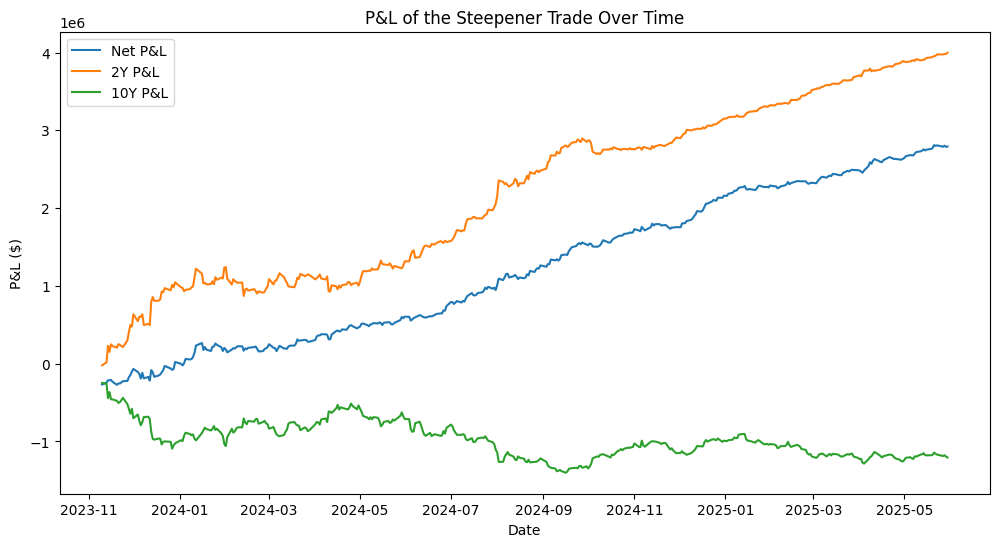

In [71]:
net_pnl = 0
net_pnl_list = []
two_year_pnl = 0
ten_year_pnl = 0
two_year_pnl_list = []
ten_year_pnl_list = []

coupon_rate_2yr = info.loc['cpn rate', 207652] 
coupon_rate_10yr = info.loc['cpn rate', 208147] 

coupon_per_bond_2yr = coupon_rate_2yr / 2  # 0.375 / 2 = 0.1875
coupon_per_bond_10yr = coupon_rate_10yr / 2  # 4.5 / 2 = 2.25

# Initialize positions on day 0
dirty_2y_init = dirty.iloc[0, :].loc[207652]
dirty_10y_init = dirty.iloc[0, :].loc[208147]
dur_2y_init = duration.iloc[0, :].loc[207652]
dur_10y_init = duration.iloc[0, :].loc[208147]

two_year_bond = long_position / dirty_2y_init
hedge_ratio = (dur_2y_init * dirty_2y_init) / (dur_10y_init * dirty_10y_init)
short_dollar = long_position * hedge_ratio
ten_year_bond = short_dollar / dirty_10y_init

last_coupon_date_2yr = None
last_coupon_date_10yr = None

for i in range(1, len(dirty)):
    date = dirty.index[i]
    
    # Store prior position (for coupon calculation)
    two_year_bond_prev = two_year_bond
    ten_year_bond_prev = ten_year_bond
    
    # Get prices
    dirty_2y_prev = dirty.iloc[i-1, :].loc[207652]
    dirty_10y_prev = dirty.iloc[i-1, :].loc[208147]
    dirty_2y_curr = dirty.iloc[i, :].loc[207652]
    dirty_10y_curr = dirty.iloc[i, :].loc[208147]
    clean_2y_curr = clean.iloc[i, :].loc[207652]
    clean_10y_curr = clean.iloc[i, :].loc[208147]


    # In your loop, replace the coupon detection with:
    if abs(dirty_2y_curr - clean_2y_curr) < 0.01:
        # Only count if we haven't already counted this coupon period
        if last_coupon_date_2yr is None or (date - last_coupon_date_2yr).days > 30:
            print(f"2 year bond on {date} is at clean price. Cashflow just got paid.")
            coupon_cash_2y = two_year_bond_prev * coupon_per_bond_2yr
            net_pnl += coupon_cash_2y
            two_year_pnl += coupon_cash_2y
            last_coupon_date_2yr = date

    if abs(dirty_10y_curr - clean_10y_curr) < 0.01:
        if last_coupon_date_10yr is None or (date - last_coupon_date_10yr).days > 30:
            print(f"10 year bond on {date} is at clean price. Cashflow just got paid.")
            coupon_cash_10y = -ten_year_bond_prev * coupon_per_bond_10yr
            net_pnl += coupon_cash_10y
            ten_year_pnl += coupon_cash_10y
            last_coupon_date_10yr = date

    # Calculate P&L from price changes
    pnl_2y = two_year_bond_prev * (dirty_2y_curr - dirty_2y_prev)
    pnl_10y = -ten_year_bond_prev * (dirty_10y_curr - dirty_10y_prev)
    
    net_pnl += pnl_2y + pnl_10y
    two_year_pnl += pnl_2y
    ten_year_pnl += pnl_10y
    
    net_pnl_list.append((date, net_pnl))
    two_year_pnl_list.append((date, two_year_pnl))
    ten_year_pnl_list.append((date, ten_year_pnl))

    # Rebalance for next period
    two_year_bond = long_position / dirty_2y_curr
    dur_2y = duration.iloc[i, :].loc[207652]
    dur_10y = duration.iloc[i, :].loc[208147]
    hedge_ratio = (dur_2y * dirty_2y_curr) / (dur_10y * dirty_10y_curr)
    short_dollar = long_position * hedge_ratio
    ten_year_bond = short_dollar / dirty_10y_curr

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot([x[0] for x in net_pnl_list], [x[1] for x in net_pnl_list], label='Net P&L')
plt.plot([x[0] for x in two_year_pnl_list], [x[1] for x in two_year_pnl_list], label='2Y P&L')
plt.plot([x[0] for x in ten_year_pnl_list], [x[1] for x in ten_year_pnl_list], label='10Y P&L')
plt.xlabel('Date')
plt.ylabel('P&L ($)')
plt.title('P&L of the Steepener Trade Over Time')
plt.legend()
plt.show()

In [72]:
print(f"Long position: ${long_position:,.2f}")
print(f"Dirty 2yr on day 0: {dirty.iloc[0, :].loc[207652]}")
print(f"Number of 2yr bonds: {two_year_bond:,.2f}")
print(f"Dirty 10yr on day 0: {dirty.iloc[0, :].loc[208147]}")
print(f"Number of 10yr bonds: {ten_year_bond:,.2f}")
print(f"Coupon per bond 2yr: ${coupon_per_bond_2yr}")
print(f"Coupon per bond 10yr: ${coupon_per_bond_10yr}")


Long position: $50,000,000.00
Dirty 2yr on day 0: 90.97826086956522
Number of 2yr bonds: 510,469.73
Dirty 10yr on day 0: 99.0
Number of 10yr bonds: 39,036.82
Coupon per bond 2yr: $0.1875
Coupon per bond 10yr: $2.25


In [73]:
total_pnl = net_pnl_list[-1][1]
print(f"Total P&L including coupons: {total_pnl:.2f} $")
difference = total_pnl - last_day_profit
print(f"Difference between prior P&L and new P&L with coupons: {difference:.2f} $")

Total P&L including coupons: 2791875.33 $
Difference between prior P&L and new P&L with coupons: -436322.14 $


- ### The total Pnl decreased by around $430 thousand due to cashflows